In [1]:
import numpy as np
from matplotlib import rc,rcParams
#matplotlib.use('Agg')
import matplotlib.pyplot as plt
from astropy.io import fits
%matplotlib inline 
import os
from astropy.table import Table
from scipy import stats
from astropy.cosmology import Planck18 as cosmo
import astropy.coordinates as coord
from scipy import stats
import statsmodels.api as sm


In [2]:
    def set_rc_params(fontsize=None):

        print("Setting Matplotlib RC parameters...")

        if fontsize is None:
            fontsize=16
        else:
            fontsize=int(fontsize)

        rc('font',**{'family':'serif'})
        rc('text', usetex=True)

        #plt.rcParams.update({'figure.facecolor':'w'})
        plt.rcParams.update({'axes.linewidth': 1.1})
        plt.rcParams.update({'xtick.labelsize': fontsize})
        plt.rcParams.update({'ytick.labelsize': fontsize})
        plt.rcParams.update({'xtick.major.size': 8})
        plt.rcParams.update({'xtick.major.width': 1.1})
        plt.rcParams.update({'xtick.minor.visible': True})
        plt.rcParams.update({'xtick.minor.width': 1.})
        plt.rcParams.update({'xtick.minor.size': 6})
        plt.rcParams.update({'xtick.direction': 'out'})
        plt.rcParams.update({'ytick.major.width': 1.1})
        plt.rcParams.update({'ytick.major.size': 8})
        plt.rcParams.update({'ytick.minor.visible': True})
        plt.rcParams.update({'ytick.minor.width': 1.})
        plt.rcParams.update({'ytick.minor.size':6})
        plt.rcParams.update({'ytick.direction':'out'})
        plt.rcParams.update({'axes.labelsize': fontsize})
        plt.rcParams.update({'axes.titlesize': fontsize})
        plt.rcParams.update({'legend.fontsize': int(fontsize-2)})

        return


In [3]:
set_rc_params(fontsize=16)

Setting Matplotlib RC parameters...


# Compare CSFD to SFD

## Start with SFD redMaGiC catalogs

## CSFD redMaGiC catalogs

In [5]:
###
### CSFD hidens, with and without bins plus one with a redshift cut
###
output_path = '/Users/j.mccleary/Research/dusty_halos/dusthalos_emh/output/redmagic_hidens_csfd/'

### NOTE: THIS HAD BUGGY WISE RANDOMS
dk_hidens_csfd = Table.read(output_path+'z_gt_0.5_dustcorrel_g23_usebins_compensated_signal.txt', header_start=1, format='ascii')
dr_hidens_csfd = Table.read(output_path+'z_gt_0.5_dustcorrel_g23_usebins_bg_randoms.txt', header_start=1, format='ascii')
fr_hidens_csfd = Table.read(output_path+'z_gt_0.5_dustcorrel_g23_usebins_fg_randoms.txt', header_start=1, format='ascii')
rr_hidens_csfd = Table.read(output_path+'z_gt_0.5_dustcorrel_g23_usebins_fgxbg_randoms.txt', header_start=1, format='ascii')

### WISE randoms have been fixed in this version
dk_hidens_newrand_csfd = Table.read(output_path+'z_gt_0.5_dustcorrel_usebins_new_wiserand_compensated_signal.txt', header_start=1, format='ascii')
dr_hidens_newrand_csfd = Table.read(output_path+'z_gt_0.5_dustcorrel_usebins_new_wiserand_bg_randoms.txt', header_start=1, format='ascii')
fr_hidens_newrand_csfd = Table.read(output_path+'z_gt_0.5_dustcorrel_usebins_new_wiserand_fg_randoms.txt', header_start=1, format='ascii')
rr_hidens_newrand_csfd = Table.read(output_path+'z_gt_0.5_dustcorrel_usebins_new_wiserand_fgxbg_randoms.txt', header_start=1, format='ascii')

### NOTE: THIS HAD BUGGY WISE RANDOMS
dk_zcut_csfd = Table.read(output_path+'z_gt_0.5_dustcorrel_wise_zlt0.11_g23_usebins_compensated_signal.txt', header_start=1, format='ascii')
dr_zcut_csfd = Table.read(output_path+'z_gt_0.5_dustcorrel_wise_zlt0.11_g23_usebins_bg_randoms.txt', header_start=1, format='ascii')
fr_zcut_csfd = Table.read(output_path+'z_gt_0.5_dustcorrel_wise_zlt0.11_g23_usebins_fg_randoms.txt', header_start=1, format='ascii')
rr_zcut_csfd = Table.read(output_path+'z_gt_0.5_dustcorrel_wise_zlt0.11_g23_usebins_fgxbg_randoms.txt', header_start=1, format='ascii')

###
### high-lum high-z CSFD
###

output_path_hiz = '/Users/j.mccleary/Research/dusty_halos/dusthalos_emh/output/redmagic_hiz_csfd/'

### NOTE: THIS HAD BUGGY WISE RANDOMS
dk_hiz_csfd = Table.read(output_path_hiz+'dustcorrel_g23_usebins_compensated_signal.txt', header_start=1, format='ascii')
dr_hiz_csfd = Table.read(output_path_hiz+'dustcorrel_g23_usebins_bg_randoms.txt', header_start=1, format='ascii')
fr_hiz_csfd = Table.read(output_path_hiz+'dustcorrel_g23_usebins_fg_randoms.txt', header_start=1, format='ascii')
raw_hiz_csfd = Table.read(output_path_hiz+'dustcorrel_g23_usebins_raw_signal.txt', header_start=1, format='ascii')
rr_hiz_csfd = Table.read(output_path_hiz+'dustcorrel_g23_usebins_fgxbg_randoms.txt', header_start=1, format='ascii')

### WISE randoms have been fixed in this version
dk_hiz_newrand_csfd = Table.read(output_path_hiz+'dustcorrel_usebins_wise_compensated_signal.txt', header_start=1, format='ascii')
dr_hiz_newrand_csfd = Table.read(output_path_hiz+'dustcorrel_usebins_wise_bg_randoms.txt', header_start=1, format='ascii')
fr_hiz_newrand_csfd = Table.read(output_path_hiz+'dustcorrel_usebins_wise_fg_randoms.txt', header_start=1, format='ascii')
raw_hiz_newrand_csfd = Table.read(output_path_hiz+'dustcorrel_usebins_wise_raw_signal.txt', header_start=1, format='ascii')
rr_hiz_newrand_csfd = Table.read(output_path_hiz+'dustcorrel_usebins_wise_fgxbg_randoms.txt', header_start=1, format='ascii')



### Read in redMaGiC LRGs

In [6]:
output_path = '/Users/j.mccleary/Research/dusty_halos/dusthalos_emh/output/lowz_hidens_fg_x_hiz_bg/'

### NOTE: THIS HAD BUGGY WISE RANDOMS
dk_lrg = Table.read(output_path+'dustcorrel_g23_5zbins_compensated_signal.txt', header_start=1, format='ascii')
dr_lrg = Table.read(output_path+'dustcorrel_g23_5zbins_bg_randoms.txt', header_start=1, format='ascii')
fr_lrg = Table.read(output_path+'dustcorrel_g23_5zbins_fg_randoms.txt', header_start=1, format='ascii')
rr_lrg = Table.read(output_path+'dustcorrel_g23_5zbins_fgxbg_randoms.txt', header_start=1, format='ascii')

### WISE randoms have been fixed in this version
dk_lrg_usebins_csfd = Table.read(output_path+'dustcorrel_g23_csfd_usebins_compensated_signal.txt', header_start=1, format='ascii')
dr_lrg_usebins_csfd = Table.read(output_path+'dustcorrel_g23_csfd_usebins_bg_randoms.txt', header_start=1, format='ascii')
fr_lrg_usebins_csfd = Table.read(output_path+'dustcorrel_g23_csfd_usebins_fg_randoms.txt', header_start=1, format='ascii')
rr_lrg_usebins_csfd = Table.read(output_path+'dustcorrel_g23_csfd_usebins_fgxbg_randoms.txt', header_start=1, format='ascii')


## Define dust vectors

In [7]:
##
## Hi-density traditional SFD
#dust_hidens = dk['kappa'] - dr['kappa'] + rr['kappa']
#dust_hidens_usebins = dk_usebins['kappa'] - dr_usebins['kappa'] + rr_usebins['kappa']
##
## Hi-density CSFD incl zcut
dust_hidens_csfd = dk_hidens_csfd['kappa'] - dr_hidens_csfd['kappa'] + rr_hidens_csfd['kappa']
dust_hidens_newrand_csfd = dk_hidens_newrand_csfd['kappa'] - dr_hidens_newrand_csfd['kappa'] + rr_hidens_newrand_csfd['kappa']
dust_hidens_zcut_csfd = dk_zcut_csfd['kappa'] - dr_zcut_csfd['kappa'] + rr_zcut_csfd['kappa']

##
## Hi-lum hi-z traditional SFD
#dust_hiz = dk_hiz['kappa'] - dr_hiz['kappa'] + rr_hiz['kappa']

##
## Hi-lum hiz CSFD dk_hiz_usebins_csfd
dust_hiz_csfd = dk_hiz_csfd['kappa'] - dr_hiz_csfd['kappa'] + rr_hiz_csfd['kappa']
dust_hiz_newrand_csfd = dk_hiz_newrand_csfd['kappa'] - dr_hiz_newrand_csfd['kappa'] + rr_hiz_newrand_csfd['kappa']

##
## redMaGic LRG sample (lowz_hidens_fg x hiz_bg)
dust_lrg = dk_lrg['kappa'] - dr_lrg['kappa'] + rr_lrg['kappa']
##
## redMaGic LRG sample (lowz_hidens_fg x hiz_bg) usebins + CSFD
dust_lrg_usebins_csfd = dk_lrg_usebins_csfd['kappa'] - dr_lrg_usebins_csfd['kappa'] + rr_lrg_usebins_csfd['kappa']


# Make some plots!

### Start with defining theory vector

In [10]:
z_theory = 0.36 # Menard
theory_kpc = cosmo.kpc_proper_per_arcmin(z_theory)
theory_r_arcmin = np.logspace(-5,5,20)
theory_r = theory_r_arcmin * theory_kpc.value * cosmo.h
coeff = 5.5e-3
av_scale = 100
av = coeff * (theory_r/av_scale)**(-0.86)

### Plot: high-density

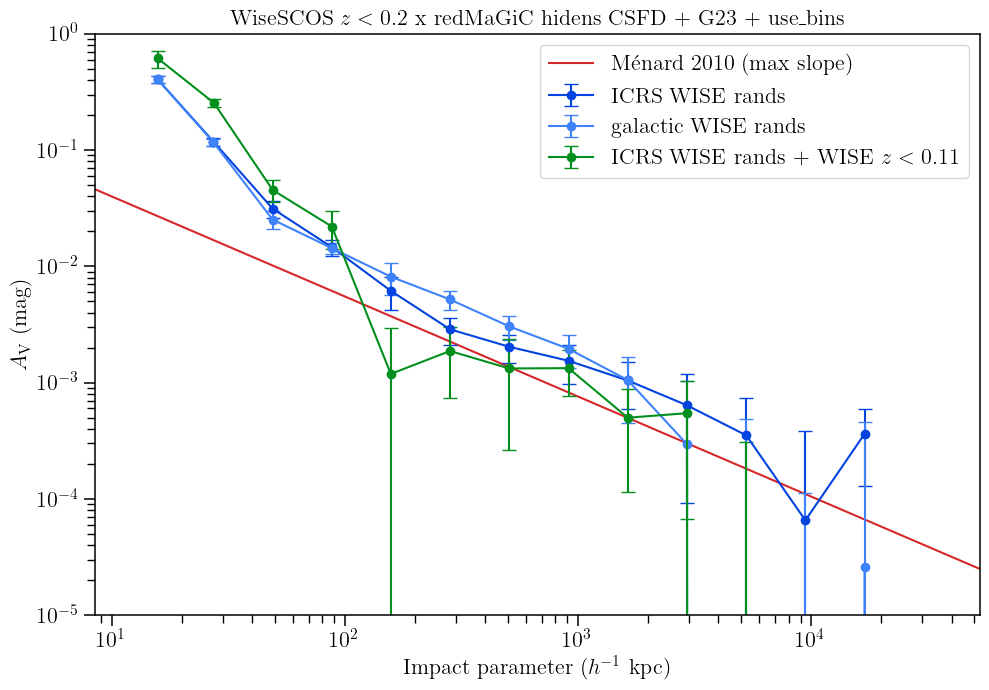

In [48]:
z_fg = 0.144 # Filtered WISExSCOS
fg_gal_kpc = cosmo.kpc_proper_per_arcmin(z_fg)

# Converts us from arcminutes to h^-1 kpc 
# Menard relationship was in terms of h
scl = fg_gal_kpc.value * cosmo.h

fig, ax = plt.subplots(figsize=(10, 7), tight_layout=True)

ax.plot(theory_r, av, color='tab:red',
        label=r'M\'{e}nard 2010 (max slope)')
# Part 1

# What it says
ax.errorbar(dk_hidens_csfd['meanr']*scl, dust_hidens_csfd,
            yerr=dk_hidens_csfd['sigma'], fmt='-o', capsize=5, 
            color='xkcd:blue', label=r'ICRS WISE rands')

ax.errorbar(dk_hidens_newrand_csfd['meanr']*scl, dust_hidens_newrand_csfd,
            yerr=dk_hidens_newrand_csfd['sigma'], fmt='-o', capsize=5, 
            color='xkcd:dodger blue', label=r'Galactic WISE rands')
'''
ax.errorbar(dk_csfd['meanr']*scl, dust_hidens_csfd,
            yerr=dk_csfd['sigma'], fmt='-o', capsize=5, 
            color='xkcd:kelly green', label=r'CSFD 5 zbins')
'''
ax.errorbar(dk_zcut_csfd['meanr']*scl, dust_hidens_zcut_csfd,
            yerr=dk_zcut_csfd['sigma'], fmt='-o', capsize=5, 
            color='xkcd:emerald green', label=r'ICRS WISE rands + WISE $z < 0.11$')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(0.08*scl, 500*scl)
ax.set_ylim(1E-5, 1)
ax.set_xlabel(r'Impact parameter ($h^{-1}$ kpc)', fontsize=16)
ax.set_ylabel(r'$A_{\rm V}$ (mag)', fontsize=16)
ax.set_title(r'WiseSCOS $z < 0.2$ x redMaGiC hidens CSFD + G23 + use\_bins', fontsize=16)
ax.legend(fontsize=16)

figname = 'dustcorrel_csfd_hidens_randcomp.png'
fig.savefig(f"/Users/j.mccleary/Research/dusty_halos/dusthalos_emh/output/{figname}" )
fig.savefig(f"/Users/j.mccleary/Research/dusty_halos/dusthalos_emh/writeup/figures_update2/{figname}" )


### Plot: high-lum high-z

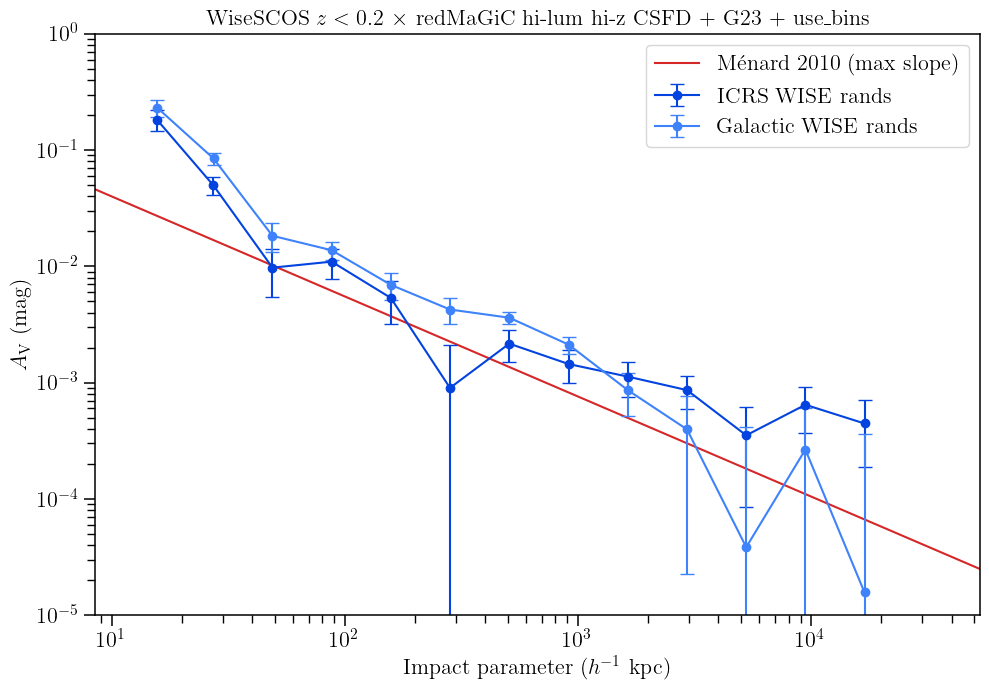

In [50]:
# Set z_theory and z_foreground levels
z_fg = 0.144 # Filtered WISExSCOS
fg_gal_kpc = cosmo.kpc_proper_per_arcmin(z_fg)

# Converts us from arcminutes to h^-1 kpc 
# Menard relationship was in terms of h
scl = fg_gal_kpc.value * cosmo.h

fig, ax = plt.subplots(figsize=(10, 7), tight_layout=True)

ax.plot(theory_r, av, color='tab:red',
        label=r'M\'{e}nard 2010 (max slope)')
# What it says
ax.errorbar(dk_hiz_csfd['meanr']*scl, dust_hiz_csfd,
            yerr=dk_hiz_csfd['sigma'], fmt='-o', capsize=5, 
            color='xkcd:blue', label=r'ICRS WISE rands')

ax.errorbar(dk_hiz_newrand_csfd['meanr']*scl, dust_hiz_newrand_csfd,
            yerr=dk_hiz_newrand_csfd['sigma'], fmt='-o', capsize=5, 
            color='xkcd:dodger blue', label=r'Galactic WISE rands')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(0.08*scl, 500*scl)
ax.set_ylim(1E-5, 1)
ax.set_xlabel(r'Impact parameter ($h^{-1}$ kpc)', fontsize=16)
ax.set_ylabel(r'$A_{\rm V}$ (mag)', fontsize=16)
ax.set_title(r'WiseSCOS $z < 0.2 \ \times $ redMaGiC hi-lum hi-z CSFD + G23 + use\_bins', fontsize=16)
ax.legend(fontsize=16)

figname = 'dustcorrel_csfd_hiz_randcomp.png'
fig.savefig(f"/Users/j.mccleary/Research/dusty_halos/dusthalos_emh/output/{figname}" )
fig.savefig(f"/Users/j.mccleary/Research/dusty_halos/dusthalos_emh/writeup/figures_update2/{figname}" )


### Plot: redMaGiC LRG (`lowz_hidens_fg_x_hiz_bg`)

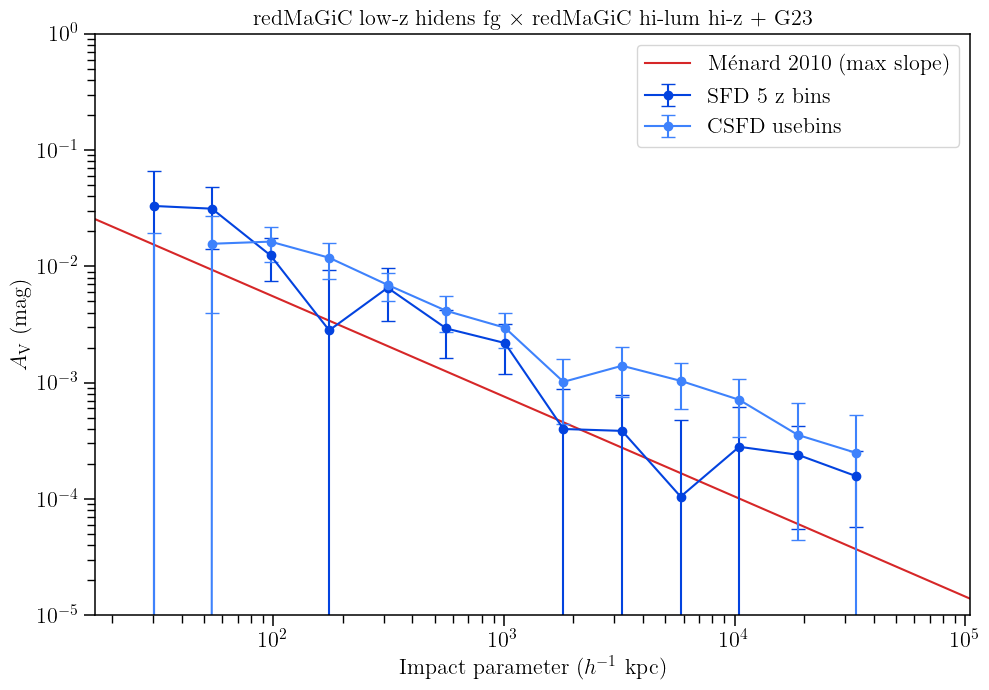

In [51]:
# Set z_theory and z_foreground levels
z_fg = 0.36 # Filtered WISExSCOS
fg_gal_kpc = cosmo.kpc_proper_per_arcmin(z_fg)

# Converts us from arcminutes to h^-1 kpc 
# Menard relationship was in terms of h
scl = fg_gal_kpc.value * cosmo.h

fig, ax = plt.subplots(figsize=(10, 7), tight_layout=True)

ax.plot(theory_r, av, color='tab:red',
        label=r'M\'{e}nard 2010 (max slope)')

ax.errorbar(dk_lrg['meanr']*scl, dust_lrg,
            yerr=dk_lrg['sigma'], fmt='-o', capsize=5, 
            color='xkcd:blue', label=r'SFD 5 z bins')

ax.errorbar(dk_lrg_usebins_csfd['meanr']*scl, dust_lrg_usebins_csfd,
            yerr=dk_lrg_usebins_csfd['sigma'], fmt='-o', capsize=5, 
            color='xkcd:dodger blue', label=r'CSFD usebins')


ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(0.08*scl, 500*scl)
ax.set_ylim(1E-5, 1)
ax.set_xlabel(r'Impact parameter ($h^{-1}$ kpc)', fontsize=16)
ax.set_ylabel(r'$A_{\rm V}$ (mag)', fontsize=16)
ax.set_title(r'redMaGiC low-z hidens fg $\times$ redMaGiC hi-lum hi-z + G23', fontsize=16)
ax.legend(fontsize=16)

figname = 'dustcorrel_lowz_hidens_fg_x_hiz_bg_csfd_comp2.png'
fig.savefig(f"/Users/j.mccleary/Research/dusty_halos/dusthalos_emh/output/{figname}" )
fig.savefig(f"/Users/j.mccleary/Research/dusty_halos/dusthalos_emh/writeup/figures_update2/{figname}" )


### Plot: all CSFD samples

In [ ]:
# Set z_theory and z_foreground levels
z_fg = 0.13
z_fg2 = 0.36 # Filtered WISExSCOS
fg_gal_kpc = cosmo.kpc_proper_per_arcmin(z_fg)
fg_gal_kpc2 = cosmo.kpc_proper_per_arcmin(z_fg)

# Converts us from arcminutes to h^-1 kpc 
# Menard relationship was in terms of h
scl = fg_gal_kpc.value * cosmo.h
scl2 = fg_gal_kpc2.value * cosmo.h

fig, ax = plt.subplots(figsize=(10, 7), tight_layout=True)

ax.plot(theory_r, av, color='tab:red',
        label=r'M\'{e}nard+ 2010 (upper lim.)')
# What it says

ax.errorbar(dk_hiz_usebins_csfd['meanr']*scl, dust_hiz_usebins_csfd,
            yerr=dk_hiz_usebins_csfd['sigma'], fmt='-o', capsize=5, 
            color='xkcd:dodger blue', label=r'WISE $\times$ hilum hiz')

ax.errorbar(dk_usebins_csfd['meanr']*scl, dust_hidens_usebins_csfd,
            yerr=dk_usebins_csfd['sigma'], fmt='-o', capsize=5, 
            color='xkcd:blue', label=r'WISE $\times$ hidens $z>0.5$')

ax.errorbar(dk_lrg_usebins_csfd['meanr']*scl2, dust_lrg_usebins_csfd,
            yerr=dk_lrg_usebins_csfd['sigma'], fmt='-o', capsize=5, 
            color='xkcd:indian red', label=r'redMaGiC LRGs')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(0.08*scl, 500*scl)
ax.set_ylim(1E-5, 1)
ax.set_xlabel(r'Impact parameter ($h^{-1}$ kpc)', fontsize=16)
ax.set_ylabel(r'$A_{\rm V}$ (mag)', fontsize=16)
#ax.set_title(r'', fontsize=16)
ax.legend(fontsize=16)

figname = 'dustcorrel_redmagic_csfd_comp.png'
fig.savefig(f"/Users/j.mccleary/Research/dusty_halos/dusthalos_emh/output/{figname}" )
fig.savefig(f"/Users/j.mccleary/Research/dusty_halos/dusthalos_emh/writeup/figures_update2/{figname}" )


# Calculate fits

In [ ]:
def do_WLS_fit(this_dk, dust_rel, name=None, start=None, end=None, log=False):
    """
    Perform a weighted least-squares linear regression to
    data, taking care to transform the variables appropriately.

    Inputs
        this_dk: should be the 'compensated' treecorr output
        dust_rel: the corrected A_V relationship (dk-dr+rr)
        name: what are we calling it?
        start: exclude points with index < 'start' for fitting
        end: ibidem, but for points with index > 'end'
        log: if True, fit the relationship in log-space to stabilize the fits.
             Default is False.
    """

    ## Transform the dependent variable (fully compensated kappa)
    if log == True:
        Y = np.log(dust_rel[start:end])        
        ## Also need to transform the weights!
        weights_OG = 1/(this_dk['sigma'][start:end]**2)
        weight_scale = (1/Y)**2
        #weight_scale = (1/(Y+1))**2
        weights = weights_OG * weight_scale
    
    ## Just do regular fit
    else:
        Y = dust_rel[start:end]
        weights = 1/(this_dk['sigma'][start:end]**2)
    
    ## If plotting X on a log-scale, which we are, 
    ## fit relationship on log scale
    X = this_dk['meanlogr'][start:end]

    ## Add intercept to abscissa
    X = sm.add_constant(X)

    ## Do fit
    mod_wls = sm.WLS(Y, X, weights=weights)
    res_wls = mod_wls.fit()

    ## Print results
    print("")
    print(f"Fit result: {name}")
    print("")
    print(res_wls.summary())

    return(res_wls)

In [ ]:
res_hiz = do_WLS_fit(
    dk_hiz_rand3_csfd, dust_hiz_rand3_csfd, 
    name='high-lum high-z', start=3, end=10, log=True
)
print(res_hiz.params)
print(f"Fit: {np.exp(res_hiz.params[0]):.2e} * (meanr)^{res_hiz.params[1]:.2f}")

res_hiz_inner = do_WLS_fit(
    dk_hiz_usebins_csfd, dust_hiz_usebins_csfd, 
    name='high-lum high-z inner', start=0, end=4, log=True
)
print(res_hiz_inner.params)
print(f"Fit: {np.exp(res_hiz_inner.params[0]):.2e} * (meanr)^{res_hiz_inner.params[1]:.2f}")

In [ ]:
res_hidens = do_WLS_fit(
    dk_usebins_csfd, dust_hidens_usebins_csfd, 
    name='high-density', start=3, log=True
)
print(res_hidens.params)
print(f"Fit: {np.exp(res_hidens.params[0]):.2e} * (meanr)^{res_hidens.params[1]:.2f}")

res_hidens_inner = do_WLS_fit(
    dk_usebins_csfd, dust_hidens_usebins_csfd, 
    name='high-density inner', start=0, end=4, log=True
)
print(res_hidens_inner.params)
print(f"Fit: {np.exp(res_hidens_inner.params[0]):.2e} * (meanr)^{res_hidens_inner.params[1]:.2f}")

In [ ]:
res_lrg = do_WLS_fit(
    dk_lrg_usebins_csfd, dust_lrg_usebins_csfd, 
    name='redmagic LRG', start=5, log=True
)
print(res_lrg.params)
print(f"Fit: {np.exp(res_lrg.params[0]):.2e} * (meanr)^{res_lrg.params[1]:.2f}")

In [ ]:
linregress_lrg = stats.linregress(
    dk_lrg_usebins_csfd['meanlogr'][5:], 
    np.log(dust_lrg_usebins_csfd[5:])
)
linregress_hiz = stats.linregress(
    dk_hiz_usebins_csfd['meanlogr'][4:], 
    np.log(dust_hiz_usebins_csfd[4:])
)
linregress_hidens = stats.linregress(
    dk_usebins_csfd['meanlogr'][4:], 
    np.log(dust_hidens_usebins_csfd[4:])
)

print("LRG params")
print(linregress_lrg)
print("")

print("high-dens params")
print(linregress_hidens)
print("")

print("high-z params")
print(linregress_hiz)
print("")


print(f"LRG fit: {np.exp(linregress_lrg[1]):.2e} * (meanr)^{linregress_lrg[0]:.2f}")
print(f"High-z fit: {np.exp(linregress_hiz[1]):.2e} * (meanr)^{linregress_hiz[0]:.2f}")
print(f"High-dens fit: {np.exp(linregress_hidens[1]):.2e} * (meanr)^{linregress_hidens[0]:.2f}")

print(f"intercept stderr: {linregress_hidens.intercept_stderr:.2e}")

### Last step: plots with fits :-) 

# Gaia plots, should do those too

In [ ]:
output_path = '/Users/j.mccleary/Research/dusty_halos/dusthalos_emh/output/systematics_testing/gaia_fg/'
'''
dk_gaia1 = Table.read(output_path+'dustcorrel_hidens_g23_usebins_compensated_signal.txt', header_start=1, format='ascii')
dr_gaia1 = Table.read(output_path+'dustcorrel_hidens_g23_usebins_bg_randoms.txt', header_start=1, format='ascii')
fr_gaia1 = Table.read(output_path+'dustcorrel_hidens_g23_usebins_fg_randoms.txt', header_start=1, format='ascii')
rr_gaia1 = Table.read(output_path+'dustcorrel_hidens_g23_usebins_fgxbg_randoms.txt', header_start=1, format='ascii')
'''
dk_gaia1 = Table.read(output_path+'dustcorrel_hidens_usebins_compensated_signal.txt', header_start=1, format='ascii')
dr_gaia1 = Table.read(output_path+'dustcorrel_hidens_usebins_bg_randoms.txt', header_start=1, format='ascii')
fr_gaia1 = Table.read(output_path+'dustcorrel_hidens_usebins_fg_randoms.txt', header_start=1, format='ascii')
rr_gaia1 = Table.read(output_path+'dustcorrel_hidens_usebins_fgxbg_randoms.txt', header_start=1, format='ascii')

dk_gaia2 = Table.read(output_path+'dustcorrel_hiz_usebins_compensated_signal.txt', header_start=1, format='ascii')
dr_gaia2 = Table.read(output_path+'dustcorrel_hiz_usebins_bg_randoms.txt', header_start=1, format='ascii')
fr_gaia2 = Table.read(output_path+'dustcorrel_hiz_usebins_fg_randoms.txt', header_start=1, format='ascii')
rr_gaia2 = Table.read(output_path+'dustcorrel_hiz_usebins_fgxbg_randoms.txt', header_start=1, format='ascii')

###
### Now define signal 
### 

dust_gaia1 = dk_gaia1['kappa'] - dr_gaia1['kappa'] + rr_gaia1['kappa']
dust_gaia2 = dk_gaia2['kappa'] - dr_gaia2['kappa'] + rr_gaia2['kappa']


## Start with fitting

In [ ]:
fit_gaia_hidens = stats.linregress(dk_gaia1['meanlogr'], dust_gaia1)
fit_gaia_hiz = stats.linregress(dk_gaia2['meanlogr'], dust_gaia2)

print("Hidens Gaia\n")
print(fit_gaia_hidens)
print("")

print("Hiz Gaia\n")
print(fit_gaia_hiz)
print("")


print(f"Gaia x high-z fit: {np.exp(fit_gaia_hiz[1]):.2e} * (meanr)^{fit_gaia_hiz[0]:.2f}")
print(f"Gaia x high-dens fit: {np.exp(fit_gaia_hidens[1]):.2e} * (meanr)^{fit_gaia_hidens[0]:.2f}")


In [ ]:
res_gaia2 = do_WLS_fit(dk_gaia2, dust_gaia2, name='Gaia x high-z', log=False)
print(res_gaia2.params)
print(f"Fit: {np.exp(res_gaia2.params[0]):.2e} * (meanr)^{res_gaia2.params[1]:.2f}")

In [ ]:
res_gaia1 = do_WLS_fit(dk_gaia1, dust_gaia1, name='Gaia x high-dens', log=False)
print(res_gaia1.params)
print(f"Fit: {np.exp(res_gaia1.params[0]):.2e} * (meanr)^{res_gaia1.params[1]:.2f}")

## Plots

In [ ]:
##
## Plot Gaia x redMaGiC results
##

## gaia x high-dens sample
a = res_gaia1.params[1] # Power
b = res_gaia1.params[0] # Coefficient
fit_gaia1 = a * dk_gaia1['meanlogr'] + b

# gaia x high-lum high-z sample
fit_gaia2 = res_gaia2.params[1] * dk_gaia2['meanlogr'] + res_gaia2.params[0]

fig, axs = plt.subplots(1, 2, figsize=(15, 6), tight_layout=True)

axs[0].errorbar(dk_gaia1['meanr'], dust_gaia1,
            yerr=dk_gaia1['sigma'], fmt='-o', capsize=5, 
            label=r'hi-dens', color='xkcd:fire engine red')
axs[0].plot(dk_gaia1['meanr'], fit_gaia1, ls='--', color='xkcd:fire engine red', 
        label='hi-dens fit')

axs[0].errorbar(dk_gaia2['meanr'], dust_gaia2,
            yerr=dk_gaia2['sigma'], fmt='-o', capsize=5, 
            label=r'high-lum high-z', color='xkcd:maroon')
axs[0].plot(dk_gaia1['meanr'], fit_gaia2, ls='--', color='xkcd:maroon', 
        label='high-lum high-z fit')

axs[0].set_xscale('log')
axs[0].set_xlim(0.1, 250)
axs[0].axhline(0, linestyle='--', color='k', alpha=0.5)

axs[0].set_xlabel(r'Impact parameter (arcmin)', fontsize=16)
axs[0].set_ylabel(r'$A_{\rm V}$ (mag)', fontsize=16)
axs[0].legend(fontsize=16)

### 
### Inset
###
axs[1].errorbar(dk_gaia1['meanr'][4:], dust_gaia1[4:],
            yerr=dk_gaia1['sigma'][4:], fmt='-o', capsize=5, 
            label=r'hi-dens', color='xkcd:fire engine red')
axs[1].plot(dk_gaia1['meanr'][4:], fit_gaia1[4:], ls='--', color='xkcd:fire engine red', 
        label='hi-dens fit')

axs[1].errorbar(dk_gaia2['meanr'][4:], dust_gaia2[4:],
            yerr=dk_gaia2['sigma'][4:], fmt='-o', capsize=5, 
            label=r'high-lum high-z', color='xkcd:maroon')
axs[1].plot(dk_gaia1['meanr'][4:], fit_gaia2[4:], ls='--', color='xkcd:maroon', 
        label='high-lum high-z fit')

axs[1].set_xscale('log')
axs[1].set_xlim(1, 250)
axs[1].set_ylim(-3e-3, 6e-3)
axs[1].axhline(0, linestyle='--', color='k', alpha=0.5)

axs[1].set_xlabel(r'Impact parameter (arcmin)', fontsize=16)
#axs[1].set_ylabel(r'$A_{\rm V}$ (mag)', fontsize=16)
axs[1].legend(fontsize=16)

fig.suptitle('Gaia x redMaGiC cross-correlation', fontsize=18)

figname = 'Gaia_redmagic_crosscorrel_csfd.png'
#fig.savefig(f"/Users/j.mccleary/Research/dusty_halos/dusthalos_emh/output/{figname}" )
#fig.savefig(f"/Users/j.mccleary/Research/dusty_halos/dusthalos_emh/writeup/figures_update2/{figname}" )

# DES Star bg plots, should do those too

In [ ]:
output_path = '/Users/j.mccleary/Research/dusty_halos/dusthalos_emh/output/systematics_testing/redmagic_star_bg/'

dk_desstar = Table.read(output_path+'dustcorrel_g23_csfd_usebins_compensated_signal.txt', header_start=1, format='ascii')
dr_desstar = Table.read(output_path+'dustcorrel_g23_csfd_usebins_bg_randoms.txt', header_start=1, format='ascii')
fr_desstar = Table.read(output_path+'dustcorrel_g23_csfd_usebins_fg_randoms.txt', header_start=1, format='ascii')
rr_desstar = Table.read(output_path+'dustcorrel_g23_csfd_usebins_fgxbg_randoms.txt', header_start=1, format='ascii')

dk_desstar2 = Table.read(output_path+'dustcorrel_csfd_new_wiserand_compensated_signal.txt', header_start=1, format='ascii')
dr_desstar2 = Table.read(output_path+'dustcorrel_csfd_new_wiserand_bg_randoms.txt', header_start=1, format='ascii')
fr_desstar2 = Table.read(output_path+'dustcorrel_csfd_new_wiserand_fg_randoms.txt', header_start=1, format='ascii')
rr_desstar2 = Table.read(output_path+'dustcorrel_csfd_new_wiserand_fgxbg_randoms.txt', header_start=1, format='ascii')

###
### Now define signal 
### 

dust_desstar = dk_desstar['kappa'] - dr_desstar['kappa'] + rr_desstar['kappa']
dust_desstar2 = dk_desstar2['kappa'] - dr_desstar2['kappa'] + rr_desstar2['kappa']


## Start with fitting

In [ ]:
fit_desstar = stats.linregress(dk_desstar['meanlogr'], dust_desstar)
fit_desstar2 = stats.linregress(dk_desstar2['meanlogr'], dust_desstar2)

print("DES star background \n")
print(fit_desstar)
print("")
print(f"WISExSCOS x DES star fit: {np.exp(fit_desstar[1]):.2e} * (meanr)^{fit_desstar[0]:.2f}")

print("DES star background + updated WISE fg rand \n")
print(fit_desstar2)
print("")
print(f"WISExSCOS x DES star fit: {np.exp(fit_desstar2[1]):.2e} * (meanr)^{fit_desstar2[0]:.2f}")


In [ ]:
res_desstar = do_WLS_fit(dk_desstar, dust_desstar, name='WISExSCOS x DES star', log=False)
print(res_desstar.params)
print(f"Fit: {np.exp(res_desstar.params[0]):.2e} * (meanr)^{res_desstar.params[1]:.2f}")

In [ ]:
res_desstar2 = do_WLS_fit(dk_desstar2, dust_desstar2, name='WISExSCOS rand2 x DES star', log=False)
print(res_desstar2.params)
print(f"Fit: {np.exp(res_desstar2.params[0]):.2e} * (meanr)^{res_desstar2.params[1]:.2f}")

In [ ]:
## gaia x high-dens sample
a = res_desstar.params[1] # Power
b = res_desstar.params[0] # Coefficient
fit_desstar = a * dk_desstar['meanlogr'] + b

# gaia x high-lum high-z sample
fit_desstar2 = res_desstar2.params[1] * dk_desstar2['meanlogr'] + res_desstar2.params[0]

fig, axs = plt.subplots(1, 2, figsize=(15, 6), tight_layout=True)

axs[0].errorbar(dk_desstar['meanr'], dust_desstar,
            yerr=dk_desstar['sigma'], fmt='-o', capsize=5, 
            label=r'DES star bg', color='xkcd:fire engine red')
axs[0].plot(dk_desstar['meanr'], fit_desstar, ls='--', color='xkcd:fire engine red', 
        label='DES star fit')

axs[0].errorbar(dk_desstar2['meanr'], dust_desstar2,
            yerr=dk_desstar2['sigma'], fmt='-o', capsize=5, 
            label=r'DES star bg + WISE2', color='xkcd:maroon')
axs[0].plot(dk_desstar2['meanr'], fit_desstar2, ls='--', color='xkcd:maroon', 
        label='DES star + WISE2 fit')

axs[0].set_xscale('log')
axs[0].set_xlim(0.1, 250)
axs[0].axhline(0, linestyle='--', color='k', alpha=0.5)

axs[0].set_xlabel(r'Impact parameter (arcmin)', fontsize=16)
axs[0].set_ylabel(r'$A_{\rm V}$ (mag)', fontsize=16)
axs[0].legend(fontsize=16)

### 
### Inset
###
axs[1].errorbar(dk_desstar['meanr'][4:], dust_desstar[4:],
            yerr=dk_desstar['sigma'][4:], fmt='-o', capsize=5, 
            label=r'DES star bg', color='xkcd:fire engine red')
axs[1].plot(dk_desstar['meanr'][4:], fit_desstar[4:], ls='--', color='xkcd:fire engine red', 
        label='DES star bg fit')

axs[1].errorbar(dk_desstar2['meanr'][4:], dust_desstar2[4:],
            yerr=dk_desstar2['sigma'][4:], fmt='-o', capsize=5, 
            label=r'DES star bg + WISE2', color='xkcd:maroon')
axs[1].plot(dk_desstar2['meanr'][4:], fit_desstar2[4:], ls='--', color='xkcd:maroon', 
        label='DES star + WISE2 fit')


axs[1].set_xscale('log')
axs[1].set_xlim(2, 250)
axs[1].set_ylim(-3e-3, 3e-3)
axs[1].axhline(0, linestyle='--', color='k', alpha=0.5)

axs[1].set_xlabel(r'Impact parameter (arcmin)', fontsize=16)
#axs[1].set_ylabel(r'$A_{\rm V}$ (mag)', fontsize=16)
axs[1].legend(fontsize=16)

fig.suptitle('WISExSCOS x DES Star cross-correlation', fontsize=18)

figname = 'desstar_crosscorrel_csfd.png'